<a href="https://colab.research.google.com/github/amay1212/Assignment-ML/blob/main/Recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment Overview**:-

Objective of this challenge is to build a model to predict the probability of match from mentor and
mentee data.

**Dependent Variables**

1. mentee_major - Categorical data with list of values with respect to majors taken by mentee.

2. mentee_help_topics - Help topics is a "topic-based authoring" in the technical communication area.

3. mentee_experitse - categorical data which shows the values in topics which is expertise of mentee

4. mentor_major - Categorical data with list of values with respect to majors taken by mentor.

5. mentor_help_topics - Help topics is a "topic-based authoring" in the technical communication area.

6. mentor_experitse - Categorical data which shows the values in topics which is expertise of mentor

**Independent Variable**

1. final_match - Binary variable (0 and 1) 0 for no match between the mentee and the mentor and 1 for a match

In [ ]:
import pathlib
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import string
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from numpy import mean, std
from lightgbm import LGBMClassifier
from collections import Counter
import seaborn as sns 
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
# for rest endpoints
from flask import Flask, request, redirect, url_for, flash, jsonify
# to save the model
import pickle
import json
import portpicker
import socket
import threading
from flask_ngrok import run_with_ngrok



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
%cd /content/gdrive/My Drive/

Mounted at /content/gdrive
/content/gdrive/My Drive


In [ ]:
!ls -l

ls: 'Skin cancer ISIC The International Skin Imaging Collaboration': No such file or directory
total 29334
-rw------- 1 root root    41529 Jun 11 08:18 'Amay_Trivedi (1).pdf'
-rw------- 1 root root    41529 Jun 15 04:04  Amay_Trivedi.pdf
drwx------ 2 root root     4096 Jul  2 17:28 'Colab Notebooks'
-rw------- 1 root root      151 Jul  3 07:42 'pg_recommendation_data (1).gsheet'
-rw------- 1 root root      151 Jul  3 04:08 'pg_recommendation_data (2).gsheet'
-rw------- 1 root root      151 Jul  2 19:16 'pg_recommendation_data (3).gsheet'
-rw------- 1 root root 29947173 Jul  2 17:29  pg_recommendation_data.csv
-rw------- 1 root root      151 Jul  3 15:42  pg_recommendation_data.gsheet
lrw------- 1 root root        0 May 30 16:37 'Skin cancer ISIC The International Skin Imaging Collaboration' -> '/content/gdrive/.shortcut-targets-by-id/1GhhOj4m_xsv7pYN5eGzYmJ4tVwdbExq7/Skin cancer ISIC The International Skin Imaging Collaboration'


In [ ]:
# reading recommendation data
pg_recommend_data = pd.read_csv('pg_recommendation_data.csv')

In [ ]:
pg_recommend_data.head()

,mentee_major,mentee_help_topics,mentee_experitse,mentor_major,mentor_help_topics,mentor_experitse,final_match
0,['Accounting and Financial Management'],"['Life Skills', 'Cover Letter Review', 'Career...",['Accounting'],['Accounting and Financial Management'],"['Parenting vs. Career', 'Career / Industry Tr...","['Finance', 'Accounting']",1
1,['Information Systems Management'],"['Working Overseas', 'Life Skills', 'Startups'...","['Food & Restaurants', 'Law', 'Computer - IT S...","['Information Systems Management', 'Project Ma...","['Leadership Skills', 'Working Overseas', 'Per...","['Trade (Wholesale)', 'Government / Public Adm...",0
2,"['Cybersecurity Technology', 'Computer Network...","['Leadership Skills', 'Personal and Profession...","['Military & Defense', 'Technology', 'Computer...","['Cybersecurity Technology', 'Computer Network...","['Management', 'Resume / CV Review', 'Career /...","['Government / Public Admin', 'Computer - IT S...",1
3,['Masters of Human Resources Management'],[],['Human Resources'],['Business Administration'],"['Leadership Skills', 'Life Skills', 'Intervie...","['Human Resources', 'Advertising / Marketing',...",0
4,['Sociology'],"['Leadership Skills', 'Life Skills', 'Manageme...",['Healthcare'],['Business Administration'],"['Leadership Skills', 'Working Overseas', 'Per...","['Human Resources', 'Computer - Hardware', 'Fi...",0


In [ ]:
pg_recommend_data.columns

Index(['mentee_major', 'mentee_help_topics', 'mentee_experitse',
       'mentor_major', 'mentor_help_topics', 'mentor_experitse',
       'final_match'],
      dtype='object')

#### Exploratory Data Analysis

In [ ]:
for i, l in enumerate(pg_recommend_data["mentee_major"][:5]):
    print("list",i,"is",type(l))


list 0 is <class 'str'>
list 1 is <class 'str'>
list 2 is <class 'str'>
list 3 is <class 'str'>
list 4 is <class 'str'>


In [ ]:
#pg_recommend_data["test_mentee_major"] = pg_recommend_data["mentee_major"].apply(eval)
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
pg_recommend_data.head(20)

,mentee_major,mentee_help_topics,mentee_experitse,mentor_major,mentor_help_topics,mentor_experitse,final_match
0,['Accounting and Financial Management'],"['Life Skills', 'Cover Letter Review', 'Career...",['Accounting'],['Accounting and Financial Management'],"['Parenting vs. Career', 'Career / Industry Tr...","['Finance', 'Accounting']",1
1,['Information Systems Management'],"['Working Overseas', 'Life Skills', 'Startups'...","['Food & Restaurants', 'Law', 'Computer - IT S...","['Information Systems Management', 'Project Ma...","['Leadership Skills', 'Working Overseas', 'Per...","['Trade (Wholesale)', 'Government / Public Adm...",0
2,"['Cybersecurity Technology', 'Computer Network...","['Leadership Skills', 'Personal and Profession...","['Military & Defense', 'Technology', 'Computer...","['Cybersecurity Technology', 'Computer Network...","['Management', 'Resume / CV Review', 'Career /...","['Government / Public Admin', 'Computer - IT S...",1
3,['Masters of Human Resources Management'],[],['Human Resources'],['Business Administration'],"['Leadership Skills', 'Life Skills', 'Intervie...","['Human Resources', 'Advertising / Marketing',...",0
4,['Sociology'],"['Leadership Skills', 'Life Skills', 'Manageme...",['Healthcare'],['Business Administration'],"['Leadership Skills', 'Working Overseas', 'Per...","['Human Resources', 'Computer - Hardware', 'Fi...",0
5,['English'],[],"['Computer - IT Services', 'Computer - Hardwar...",[],"['Leadership Skills', 'Startups', 'Life Skills...","['Computer - IT Services', 'Cybersecurity', 'C...",0
6,"['Business Administration', 'Sociology', 'Proj...",[],"['Government / Public Admin', 'Human Resources...","['', 'Cybersecurity Policy', 'Management Studi...","['Leadership Skills', 'Working Overseas', 'Per...",['Government / Public Admin'],0
7,['Business Administration'],['Career Planning'],['Business Services'],"['Public Health ', 'Business Administration']",[],"['Business Services', 'Engineering', 'Retail']",1
8,"['finance', 'Management: Financial Management'...","['Leadership Skills', 'General Networking', 'C...","['Military & Defense', 'Entrepreneurship / Sta...","['Business Administration', 'Accounting and Fi...","['Leadership Skills', 'Corporate/Office Politi...","['Business Services', 'Government / Public Adm...",0
9,['Psychology'],"['Leadership Skills', 'Working Overseas', 'Lif...","['Sports & Recreation', 'Government / Public A...",['Math'],[],[],0


In [ ]:
pg_recommend_data.head()
#pg_recommend_data = pg_recommend_data.drop(columns=['test_mentee_major'])

,mentee_major,mentee_help_topics,mentee_experitse,mentor_major,mentor_help_topics,mentor_experitse,final_match
0,['Accounting and Financial Management'],"['Life Skills', 'Cover Letter Review', 'Career...",['Accounting'],['Accounting and Financial Management'],"['Parenting vs. Career', 'Career / Industry Tr...","['Finance', 'Accounting']",1
1,['Information Systems Management'],"['Working Overseas', 'Life Skills', 'Startups'...","['Food & Restaurants', 'Law', 'Computer - IT S...","['Information Systems Management', 'Project Ma...","['Leadership Skills', 'Working Overseas', 'Per...","['Trade (Wholesale)', 'Government / Public Adm...",0
2,"['Cybersecurity Technology', 'Computer Network...","['Leadership Skills', 'Personal and Profession...","['Military & Defense', 'Technology', 'Computer...","['Cybersecurity Technology', 'Computer Network...","['Management', 'Resume / CV Review', 'Career /...","['Government / Public Admin', 'Computer - IT S...",1
3,['Masters of Human Resources Management'],[],['Human Resources'],['Business Administration'],"['Leadership Skills', 'Life Skills', 'Intervie...","['Human Resources', 'Advertising / Marketing',...",0
4,['Sociology'],"['Leadership Skills', 'Life Skills', 'Manageme...",['Healthcare'],['Business Administration'],"['Leadership Skills', 'Working Overseas', 'Per...","['Human Resources', 'Computer - Hardware', 'Fi...",0


In [ ]:
# Converting the columns in the form of their existing data types

In [ ]:
class EDA(object):

  def __init__(self, df):
    self.df = df
  
  def _apply_eval(self, col):
    # this method converts the column value to its respective data-type, 
    return self.df[col].apply(eval)

  def _data_cleaning(self, column_values):
    # this method is used for data cleaning purpose
    if isinstance(column_values, str):
      return []

    return [''.join(ch for ch in val if ch not in set(string.punctuation)).lower()
    .strip().replace('\u200c', '')
    .replace(':', '') for val in column_values]
    
    # for val in values:
    #   n_val = ''.join(ch for ch in val if ch not in set(string.punctuation)).lower().strip().replace('\u200c', '').replace(':', '')
    #   cleaned.append(n_val)
    
  def sanitize_data(self):
    # this method iterates over the columns od df and send it to data_cleaning for refining the data.
    for column_name in self.df.columns[:-1]: # iteritems is a generator object 
      
      self.df[column_name] = self._apply_eval(column_name)
      self.df[column_name] = self.df[column_name].apply(lambda val: self._data_cleaning(val))

    print("Data has been sanitized!!")
    print(self.df.head())

  def plot_corr(self, x_train):
    # plots correlation graph, TODO
    plt.figure(figsize = (20,10))
    sns.heatmap(x_train.corr(),annot = True)
    plt.show()
  
  def get_common_entities(self, col1, col2):
    # trying to find the common set of values from mentee and mentor
    stop_words = stopwords.words('english')
    filtered_words = []
    #print(self.df[col1][:1], self.df[col2][:1])
    for col1, col2 in zip(self.df[col1], self.df[col2]):

      final_list = [*col1, *col2]
      words = ' '.join(final_list)

      filtered = [word for word in words.split() if word not in stop_words]
      filtered_words.append(len([k for k, v in Counter(filtered).items() if v > 1]))

    return filtered_words
    
    #existing code has the following line TODO: remove the below line once it functions well
    #return [len(set(col1) & set(col2)) for col1, col2 in zip(self.df[col1], self.df[col2])]

  def feature_engineering_columns(self):
    # we are checking the correlation between different features 
    self.df['major_intersection'] = self.get_common_entities('mentee_major', 'mentor_major')
    self.df['helptopics_intersection'] = self.get_common_entities('mentee_help_topics', 'mentor_help_topics')
    self.df['expertise_intersection'] = self.get_common_entities('mentee_experitse', 'mentor_experitse')
    

    majors = self.sample_match_percentage('mentee_major', 'mentor_major')
    help_topics = self.sample_match_percentage('mentee_help_topics', 'mentor_help_topics')
    expertise =  self.sample_match_percentage('mentee_experitse', 'mentor_experitse')

    self.df['avg_score'] = self.get_probability(majors, help_topics, expertise, len(self.df))

  def sample_match_percentage(self, mentee_col1, mentor_col2):
    count = {}
    #match_results = [] TODO: remove this unnecessary code
    i=0
    # we sample our dataset with 10 rows and random state 1 for reproducibility of results...
    #df_sample = df.sample(n=n_sample, random_state=1)
    #print(len(df_sample))
    col1_values, col2_values = self.df[mentee_col1], self.df[mentor_col2]

    for mentee_val, mentor_val in zip(col1_values, col2_values):
      # we need to filter the mentee and mentors list because they have some null values
      
      filtered_mentee = [col_val for col_val in mentee_val if col_val]
      filtered_mentor = [col_val for col_val in mentor_val if col_val]

      unique_col1 = set(filtered_mentee)
      unique_col2 = set(filtered_mentor)
      common = unique_col1 & unique_col2
      all = unique_col1.union(unique_col2)
      count[i] = (list(common), list(all))
      i+=1

    return count

  def get_probability(self, majors, topics, expertises, n_sample):
    
    # for all the columns present in the dataframe, this returns the mean score
    # this is a feature engineering column and not present in the dataset.
    # we are trying to find the best correlation with the match, 
    # probability scores may help us improving our model as we have less features in hand

    avg_scores = []
    for i in range(0, n_sample):
      total_elem = len(majors[i][1]) + len(topics[i][1]) + len(expertises[i][1])
      weighted_avg = len(majors[i][0]) + len(topics[i][0]) + len(expertises[i][0])
      if total_elem == 0:
        avg_scores.append(0)
        continue
      avg_score = round(float(weighted_avg/total_elem), 2)
      #print("For row {} of df, the probability of getting a match is {}".format(i, avg_score))
      avg_scores.append(avg_score)

    return avg_scores

  # majors, sampled = sample_match_percentage('mentee_major', 'mentor_major', final_match_0, n_sample=len(final_match_0))  


In [ ]:
eda = EDA(pg_recommend_data)
eda.sanitize_data()


Data has been sanitized!!
                                        mentee_major  ... final_match
0              [accounting and financial management]  ...           1
1                   [information systems management]  ...           0
2  [cybersecurity technology, computer networks a...  ...           1
3            [masters of human resources management]  ...           0
4                                        [sociology]  ...           0

[5 rows x 7 columns]


In [ ]:
# eda.df.head(20)
eda.feature_engineering_columns()
eda.df.head()

,mentee_major,mentee_help_topics,mentee_experitse,mentor_major,mentor_help_topics,mentor_experitse,final_match,major_intersection,helptopics_intersection,expertise_intersection,avg_score
0,[accounting and financial management],"[life skills, cover letter review, career plan...",[accounting],[accounting and financial management],"[parenting vs career, career industry trends]","[finance, accounting]",1,3,6,1,0.23
1,[information systems management],"[working overseas, life skills, startups, care...","[food restaurants, law, computer it services...","[information systems management, project manag...","[leadership skills, working overseas, personal...","[trade wholesale, government public admin, te...",0,3,13,7,0.35
2,"[cybersecurity technology, computer networks a...","[leadership skills, personal and professional ...","[military defense, technology, computer it s...","[cybersecurity technology, computer networks a...","[management, resume cv review, career indust...","[government public admin, computer it servic...",1,4,6,4,0.32
3,[masters of human resources management],[],[human resources],[business administration],"[leadership skills, life skills, interviewing ...","[human resources, advertising marketing, tele...",0,0,1,2,0.09
4,[sociology],"[leadership skills, life skills, management, c...",[healthcare],[business administration],"[leadership skills, working overseas, personal...","[human resources, computer hardware, finance,...",0,0,13,10,0.11


In [ ]:
df = eda.df

In [ ]:
df['major_intersection'].value_counts()

0     14102
1     11299
2     10062
3     10014
4      2159
5       680
6       370
7       136
8        39
9        17
10        3
11        1
Name: major_intersection, dtype: int64

In [ ]:
df['expertise_intersection'].value_counts()[:10]

2    7726
0    7136
1    7099
3    5872
4    4176
5    3739
6    2671
7    1918
8    1476
9     979
Name: expertise_intersection, dtype: int64

In [ ]:
df['helptopics_intersection'].value_counts()[:10]

0    16608
1     7097
3     4916
2     3437
4     2662
5     2092
6     1584
7     1582
8     1491
9     1340
Name: helptopics_intersection, dtype: int64

**Plotting different correlations between intersection and final match target variables**

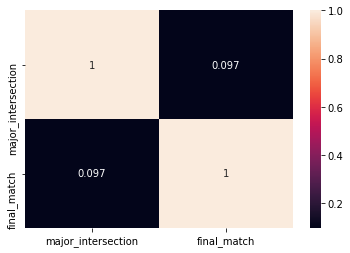

In [ ]:
sns.heatmap(pg_recommend_data[['major_intersection','final_match']].corr(), annot=True)

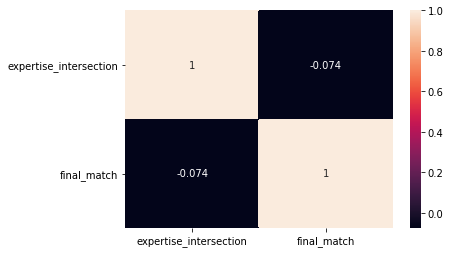

In [ ]:
sns.heatmap(pg_recommend_data[['expertise_intersection','final_match']].corr(), annot=True)


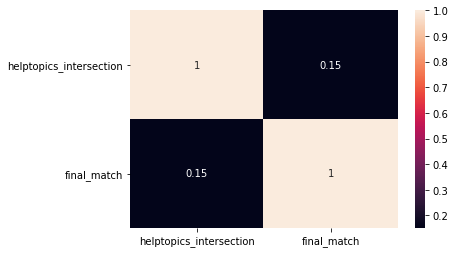

In [ ]:

sns.heatmap(pg_recommend_data[['helptopics_intersection','final_match']].corr(), annot=True)

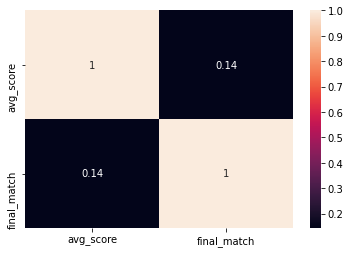

In [ ]:
sns.heatmap(pg_recommend_data[['avg_score','final_match']].corr(), annot=True)

In [ ]:
df[['major_intersection', 'expertise_intersection', 'helptopics_intersection', 'avg_score']].apply(lambda x : pd.factorize(x)[0]).corr(method='pearson', min_periods=1)


,major_intersection,expertise_intersection,helptopics_intersection,avg_score
major_intersection,1.000000,0.028572,-0.027949,-0.095315
expertise_intersection,0.028572,1.000000,0.136702,-0.035394
helptopics_intersection,-0.027949,0.136702,1.000000,0.107620
avg_score,-0.095315,-0.035394,0.107620,1.000000


**Conclusion**:

No significant higher correlation in columns, we can make the corr matrix with respect to final match target variable to see what all features are correlated.

**Building our Model Builder Class**

In [ ]:
class ModelBuilder(EDA):

  def __init__(self, df, model):
    super().__init__(df)
    model_df = self.df[['major_intersection', 'helptopics_intersection', 'expertise_intersection', 'final_match', 'avg_score']]
    X = model_df.drop('final_match',axis = 1)
    y = model_df.final_match
    self.x_train, self.x_test, self.y_train, self.y_test = train_test_split(X, y, random_state=4)
    self.model = model

  def fit_model(self, best_params=None):
    
    if best_params:
      return self.model

    model = self.model()
    model.fit(self.x_train, self.y_train)

    return model

  def hypertune_models(self, grid):
    
    model = self.model()
    #define grid search
    # grid = dict(n_estimators=n_estimators,max_features=max_features)
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
    grid_search = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)
    grid_result = grid_search.fit(self.x_train, self.y_train)
    # summarize results
    best_score, best_params = grid_result.best_score_, grid_result.best_params_
    print("Best: {} using {}".format(grid_result.best_score_, grid_result.best_params_))
    means = grid_result.cv_results_['mean_test_score']
    stds = grid_result.cv_results_['std_test_score']
    params = grid_result.cv_results_['params']
    for mean, stdev, param in zip(means, stds, params):
        print("{} {} with: {}".format(mean, stdev, param))

    return best_score, best_params
    
  def fetch_accuracy_score(self, model):
    y_test_pred = model.predict(self.x_test)

    return round(accuracy_score(self.y_test, y_test_pred), 2)
  
  def draw_roc_auc_curve(self):
    pass


In [ ]:
def model_builder(model_name, hyper_params=None, best_params=False, plot_corr=False):
  model = ModelBuilder(pg_recommend_data, model_name)
  if plot_corr:
    model.plot_corr(model.x_train)
  if best_params:
    return model
  #model.create_model(LogisticRegression)
  score, params = None, None
  model_clf = model.fit_model()

  if hyper_params:
    grid = hyper_params['grid']
    score, params = model.hypertune_models(grid)
    
  acc = model.fetch_accuracy_score(model_clf)
  print("Accuracy score is {}".format(acc))
  return acc, score, params

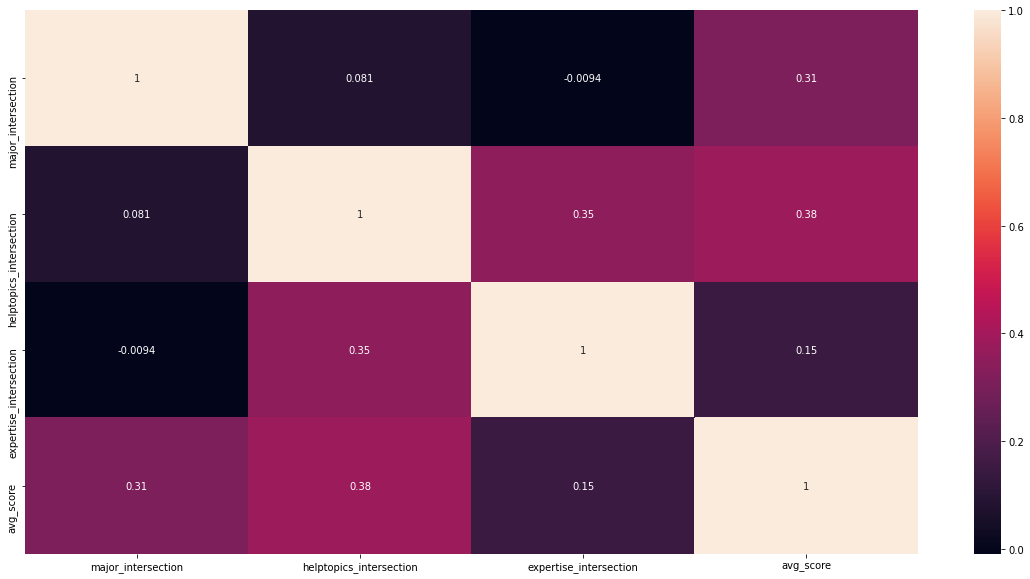

Accuracy score is 0.62


In [ ]:
acc, _, _ = model_builder(LogisticRegression, plot_corr=True)

**Conclusion**:

We are able to get correlated features now upto certain extent by applying our feature engineering columns.

In [ ]:
solvers = ['newton-cg', 'lbfgs', 'liblinear']
penalty = ['l2']
c_values = [100, 10, 1.0, 0.1, 0.01]
# define grid search
grid = dict(solver=solvers,penalty=penalty,C=c_values)
acc, score, params = model_builder(LogisticRegression, hyper_params={'grid': grid})

Best: 0.6108671914119 using {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
0.6102670922194099 0.0074915233134237895 with: {'C': 100, 'penalty': 'l2', 'solver': 'newton-cg'}
0.610276184781694 0.0074985533858509075 with: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
0.6102670922194099 0.0074915233134237895 with: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
0.6103125550308302 0.0074865183125988055 with: {'C': 10, 'penalty': 'l2', 'solver': 'newton-cg'}
0.6103125550308302 0.007461962263788829 with: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
0.610294369906262 0.007456224758912457 with: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
0.6103852905699739 0.007349581084253269 with: {'C': 1.0, 'penalty': 'l2', 'solver': 'newton-cg'}
0.6103852905699739 0.007361046018015901 with: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
0.6103852905699739 0.007361046018015901 with: {'C': 1.0, 'penalty': 'l2', 'solver': 'liblinear'}
0.6107398980194876 0.0074821201868015205 with: {'C': 0.1, 'pe

In [ ]:
model = model_builder(LogisticRegression, best_params=True)
model1 = LogisticRegression(C=params['C'], penalty=params['penalty'], solver=params['solver'])
logistic_clf_tuned = model1.fit(model.x_train, model.y_train)
model.fetch_accuracy_score(logistic_clf_tuned)

After hyper parameter tuning, our model accuracy remains the same


In [ ]:
model = model_builder(LGBMClassifier, best_params=True)
final_model = LGBMClassifier()
final_model.fit(model.x_train, model.y_train)
filename = 'finalized_model.sav'
pickle.dump(final_model, open(filename, 'wb'))


# load the model from disk
loaded_model = pickle.load(open(filename, 'rb'))

result = loaded_model.score(model.x_test, model.y_test)
print(result)

0.6301448326650847


We are able to increase our accuracy to 63% by using LGBM




**Exposing REST API Endpoint**

In [ ]:
!pip install flask_ngrok

In [ ]:
app = Flask(__name__)

run_with_ngrok(app)
@app.route('/api/', methods=['POST'])
def make_predictions():
    data = request.get_json()
    eda = EDA(pd.DataFrame(data))
    eda.feature_engineering_columns()
    prediction = np.array2string(model.predict(eda.df))

    return jsonify(prediction)

@app.route("/")
def hello():
    return "Hello World!"

if __name__ == '__main__':
    modelfile = 'finalized_model.sav'
    model = pickle.load(open(modelfile, 'rb'))
    app.run()
    #threading.Thread(target=app.run, kwargs={'host':'0.0.0.0','port':80}).start() 

172.28.0.2
 * Serving Flask app "__main__" (lazy loading)
 * Environment: production
   Use a production WSGI server instead.
 * Debug mode: off
 * Running on http://4ff6828b9025.ngrok.io
 * Traffic stats available on http://127.0.0.1:4040


127.0.0.1 - - [06/Jul/2021 04:47:06] "POST / HTTP/1.1" 405 -
127.0.0.1 - - [06/Jul/2021 04:47:27] "POST / HTTP/1.1" 405 -
127.0.0.1 - - [06/Jul/2021 04:47:35] "POST / HTTP/1.1" 405 -


In [ ]:
# Sample code to interact with the API, this may have some problems with google colab interaction

# url = 'http://4ff6828b9025.ngrok.io/'
# test_data = [[1 , 5,  2,   0.07]]
# j_data = json.dumps(test_data)
# headers = {'content-type': 'application/json', 'Accept-Charset': 'UTF-8'}
# r = requests.post(url, data=j_data, headers=headers)
# print(r, r.text)

**Business Insights**

1. There is correlation between the average scores of majors, help topics and expertises. Based on the intersection I could find that there is an impact of averaging of all the scores.

2. Help topics had a significantly higher correlation with the final match score, This maybe due to the reason that when help topics are meaningful, Help topics may help discuss ideas from mentors and mentees and similar information can be used to find a match.

**Metrics Used**

Accuracy: 

I have used the accuracy measure metric due to the reason that this dataset does not suffer from class imbalance.

**Futher Improvements**:

1. More number of features can be added to bring some more insights.

2. Using Word2vec or Glove to convert the values present in a list may let us enable to dive into more semantic relationship which can led to further creation of more derived columns.